In [12]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error
import xgboost as xgb

import pathlib
model_dir = pathlib.Path.cwd().parent
MODEL_PATH = model_dir / "models"/"xgb_demand_forecast_j+1.pkl"
base_dir = pathlib.Path.cwd().parent
DATA_PATH = base_dir / "datasets" / "synthetic_blood_transfusion.csv"
#DATA_PATH = "synthetic_blood_transfusion.csv"


In [38]:
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

# MUST be sorted for time series + group lags
df = df.sort_values(["hospital", "blood_type", "date"]).reset_index(drop=True)

print(df.shape)
df.head()
print(df.columns.tolist())


(46752, 23)
['date', 'hospital', 'dow', 'weekend', 'month', 'holiday', 'temp_c', 'rain_mm', 'flu_index', 'trauma_cases', 'scheduled_surgeries', 'donation_campaign', 'supply_shock', 'blood_type', 'stock_start', 'units_collected', 'units_used', 'wastage', 'stock_end', 'critical_stock', 'stockout_next_day', 'heavy_demand', 'heavy_demand_next_day']


In [14]:

leak_cols = ["stockout_next_day", "heavy_demand", "heavy_demand_next_day"]

existing = [c for c in leak_cols if c in df.columns]
if existing:
    df = df.drop(columns=existing)

print("Dropped:", existing)


Dropped: ['stockout_next_day', 'heavy_demand', 'heavy_demand_next_day']


In [15]:
g = df.groupby(["hospital", "blood_type"], sort=False)

# Demand history features (past-only)
df["lag1"]  = g["units_used"].shift(1)
df["lag7"]  = g["units_used"].shift(7)
df["lag30"] = g["units_used"].shift(30)

df["roll7"]  = g["units_used"].transform(lambda s: s.shift(1).rolling(7,  min_periods=7).mean())
df["roll30"] = g["units_used"].transform(lambda s: s.shift(1).rolling(30, min_periods=30).mean())


In [16]:
def make_matrices(df, H, feature_cols, test_quantile=0.8):
    """Create horizon-safe train/test matrices for forecasting units_used at t+H.

    Key fix: split is done on *label_date* (date + H), so no training row's target
    leaks into the test period.
    """
    df = df.copy()
    df = df.sort_values(["hospital", "blood_type", "date"]).reset_index(drop=True)

    g = df.groupby(["hospital", "blood_type"], sort=False)

    # Target: future demand (t+H)
    df["y"] = g["units_used"].shift(-H)

    # Label date: when y happens
    df["label_date"] = df["date"] + pd.to_timedelta(H, unit="D")

    # Horizon-safe split: based on label_date (NOT feature date)
    split_label_date = df["label_date"].quantile(test_quantile)

    train = df[df["label_date"] < split_label_date].copy()
    test  = df[df["label_date"] >= split_label_date].copy()

    # One-hot encode hospital/blood_type
    X_train = pd.get_dummies(train[["hospital", "blood_type"] + feature_cols], drop_first=True)
    X_test  = pd.get_dummies(test[["hospital", "blood_type"] + feature_cols], drop_first=True)

    # Align columns
    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

    # Drop rows with missing features or missing target
    mask_train = train["y"].notna() & X_train.notna().all(axis=1)
    mask_test  = test["y"].notna() & X_test.notna().all(axis=1)

    X_train = X_train.loc[mask_train]
    y_train = train.loc[mask_train, "y"]
    X_test  = X_test.loc[mask_test]
    y_test  = test.loc[mask_test, "y"]

    # Keep original indices for later alignment (stockout calculations, etc.)
    train_idx = X_train.index
    test_idx  = X_test.index

    return X_train, y_train, X_test, y_test, split_label_date, train_idx, test_idx


def train_eval_horizon(df, H, feature_cols, test_quantile=0.8):
    X_train, y_train, X_test, y_test, split_label_date, train_idx, test_idx = make_matrices(
        df=df, H=H, feature_cols=feature_cols, test_quantile=test_quantile
    )

    model = xgb.XGBRegressor(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))

    return {
        "H": H,
        "split_label_date": split_label_date,
        "rmse": rmse,
        "y_std": float(y_test.std()),
        "model": model,
        "X_test": X_test,
        "y_test": y_test,
        "pred": pred,
        "feature_names": X_train.columns.tolist(),
        "train_idx": train_idx,
        "test_idx": test_idx
    }


In [17]:
# Option A: end-of-day, so these are legal to use
feature_cols = [
    "dow","weekend","month","holiday","temp_c","rain_mm","flu_index",
    "trauma_cases","scheduled_surgeries","donation_campaign","supply_shock",
    "stock_start","units_collected","wastage",   # allowed in option A
    "lag1","lag7","lag30","roll7","roll30"
]

# If some columns don't exist in your CSV, drop them automatically:
feature_cols = [c for c in feature_cols if c in df.columns]
missing = set([
    "dow","weekend","month","holiday","temp_c","rain_mm","flu_index",
    "trauma_cases","scheduled_surgeries","donation_campaign","supply_shock",
    "stock_start","units_collected","wastage",
    "lag1","lag7","lag30","roll7","roll30"
]) - set(feature_cols)

print("Using features:", feature_cols)
print("Missing (ignored):", sorted(missing))


Using features: ['dow', 'weekend', 'month', 'holiday', 'temp_c', 'rain_mm', 'flu_index', 'trauma_cases', 'scheduled_surgeries', 'donation_campaign', 'supply_shock', 'stock_start', 'units_collected', 'wastage', 'lag1', 'lag7', 'lag30', 'roll7', 'roll30']
Missing (ignored): []


In [18]:
results = {}
for H in [1, 7, 30]:
    r = train_eval_horizon(df, H, feature_cols)
    results[H] = r

    # Helpful: last feature-date included in training (approx)
    # label_date = feature_date + H days  => feature_date ~= label_date - H days
    train_feature_cutoff = (r["split_label_date"] - pd.to_timedelta(H, unit="D")).date()

    print(
        f"H = {H} | RMSE = {r['rmse']:.4f} | y std = {r['y_std']:.4f} "
        f"| split (label_date) @ {r['split_label_date'].date()} | train uses dates < {train_feature_cutoff}"
    )


H = 1 | RMSE = 2.3606 | y std = 3.1505 | split (label_date) @ 2023-03-15 | train uses dates < 2023-03-14
H = 7 | RMSE = 2.3706 | y std = 3.1484 | split (label_date) @ 2023-03-21 | train uses dates < 2023-03-14
H = 30 | RMSE = 2.3761 | y std = 3.1484 | split (label_date) @ 2023-04-13 | train uses dates < 2023-03-14


In [19]:
from sklearn.metrics import mean_squared_error

H = 1
X_train, y_train, X_test, y_test, split_label_date, *_ = make_matrices(df, H, feature_cols, test_quantile=0.8)

y_shuff = y_train.sample(frac=1.0, random_state=42).values

model_shuff = xgb.XGBRegressor(
    n_estimators=600, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    objective="reg:squarederror", random_state=42, n_jobs=-1
)
model_shuff.fit(X_train, y_shuff)
pred_shuff = model_shuff.predict(X_test)

rmse_shuff = float(np.sqrt(mean_squared_error(y_test, pred_shuff)))
print("RMSE shuffled (should be much worse):", rmse_shuff)
print("Split (label_date):", split_label_date.date())


RMSE shuffled (should be much worse): 3.1759875052288544
Split (label_date): 2023-03-15


In [20]:
# r = results[1]
# model = r["model"]
# feat_names = r["feature_names"]

# importances = model.feature_importances_
# imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

# imp.head(20)


In [21]:
# from sklearn.metrics import mean_absolute_error

# for H, r in results.items():
#     mae = mean_absolute_error(r["y_test"], r["pred"])
#     rmse = r["rmse"]
#     print(f"H={H} | MAE={mae:.3f} | RMSE={rmse:.3f}")


In [22]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.metrics import mean_absolute_percentage_error

# # ---- helper: safe MAPE (handles zeros) ----
# def safe_mape(y_true, y_pred, eps=1e-6):
#     y_true = np.asarray(y_true).astype(float)
#     y_pred = np.asarray(y_pred).astype(float)
#     denom = np.maximum(np.abs(y_true), eps)
#     return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

# # ---- define a stockout proxy from predicted demand (Option A: end-of-day) ----
# # Here: stockout if predicted stock_end(t+h) < 0 using:
# # stock_end(t) + units_collected(t) - wastage(t) - predicted_demand(t+h)
# # This is a SIMPLE proxy. (Better rollout comes later.)
# def stockout_recall_proxy(df, H, y_pred, split_date, threshold=0):
#     """
#     Computes recall of stockout prediction on the test period only.
#     Uses the SAME split_date as your demand model.
#     """
#     df2 = df.copy()
#     df2["date"] = pd.to_datetime(df2["date"])
#     df2 = df2.sort_values(["hospital","blood_type","date"]).reset_index(drop=True)

#     # Align test rows where y exists (same way as model) by recomputing y index mask.
#     g = df2.groupby(["hospital","blood_type"], sort=False)
#     df2["y"] = g["units_used"].shift(-H)

#     test = df2[df2["date"] >= split_date].copy()

#     # Build same feature NaN mask as earlier: y must exist
#     mask = test["y"].notna()

#     test = test.loc[mask].copy()

#     # Now y_pred must match length of test used for prediction
#     # If your pipeline dropped more rows (NaN in features), align by using the same indices:
#     # We'll assume your `results[H]["y_test"]` corresponds to this filtered set.
#     # So we use y_pred and y_true_stockout derived from those rows only.
#     # To be safe, truncate to min length.
#     n = min(len(test), len(y_pred))
#     test = test.iloc[:n].copy()
#     y_pred = np.asarray(y_pred[:n]).astype(float)

#     # "True" stockout based on observed stock_end at day (t+H) if available:
#     # But in your data, stock_end is same-day. We can approximate true stockout at t+H by shifting stock_end.
#     test["stock_end_future"] = g["stock_end"].shift(-H).loc[test.index].values
#     y_true_stockout = (test["stock_end_future"] < threshold).astype(int).values

#     # Pred stock_end_future proxy:
#     # Start from today's stock_end and subtract predicted future demand, add today's collected/wastage (proxy)
#     pred_stock_future = (test["stock_end"].values
#                          + test["units_collected"].values
#                          - test["wastage"].values
#                          - y_pred)
#     y_pred_stockout = (pred_stock_future < threshold).astype(int)

#     # Recall = TP / (TP + FN)
#     tp = np.sum((y_true_stockout == 1) & (y_pred_stockout == 1))
#     fn = np.sum((y_true_stockout == 1) & (y_pred_stockout == 0))
#     recall = tp / (tp + fn + 1e-9)
#     return float(recall)

# # ---- build results_df ----
# rows = []
# for H, r in results.items():
#     y_true = r["y_test"].values if hasattr(r["y_test"], "values") else np.asarray(r["y_test"])
#     y_pred = r["pred"]

#     rmse = r["rmse"]
#     mape = safe_mape(y_true, y_pred)

#     # Stockout recall proxy (optional)
#     stockout_recall = stockout_recall_proxy(
#         df=df, H=H, y_pred=y_pred, split_date=r["split_date"], threshold=0
#     )

#     rows.append({
#         "Horizon": f"J+{H}",
#         "Model": "XGBoost",
#         "RMSE": rmse,
#         "MAPE": mape,
#         "Stockout_Recall": stockout_recall
#     })

# results_df = pd.DataFrame(rows)
# results_df


In [23]:
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# metrics = ["RMSE", "MAPE", "Stockout_Recall"]

# for idx, metric in enumerate(metrics):
#     pivot = results_df.pivot(index="Horizon", columns="Model", values=metric)
#     pivot.plot(kind="bar", ax=axes[idx], title=metric)
#     axes[idx].set_ylabel(metric)
#     axes[idx].tick_params(axis="x", rotation=0)
#     axes[idx].legend()

# plt.tight_layout()
# plt.show()


In [24]:
import numpy as np

print("Global stock_end < 5 rate:", (df["stock_end"] < 5).mean())
print("Global stock_end < critical_stock rate:", (df["stock_end"] < df["critical_stock"]).mean())

# More relevant: positive rate on each horizon's TEST rows (aligned with evaluation)
for H in [1, 7, 30]:
    idx = results[H]["X_test"].index
    print("Global stock_end < 5 rate:", (df["stock_end"] < 5).mean())
    print("Global stock_end < critical_stock rate:", (df["stock_end"] < df["critical_stock"]).mean())

    # Create future stock_end labels (if not already created)
    df = df.sort_values(["hospital","blood_type","date"]).reset_index(drop=True)
    g = df.groupby(["hospital","blood_type"], sort=False)
    for H in [1, 7, 30]:
        if f"stock_end_future_{H}" not in df.columns:
            df[f"stock_end_future_{H}"] = g["stock_end"].shift(-H)

    # More relevant: positive rate on each horizon's TEST rows (aligned with evaluation)
    for H in [1, 7, 30]:
        idx = results[H]["X_test"].index
        pos_rate = (df.loc[idx, f"stock_end_future_{H}"] < df.loc[idx, "critical_stock"]).mean()
        print(f"TEST positive rate (stock_end_future_{H} < critical_stock@t): {pos_rate:.3f}  | H={H}")
    print(f"TEST positive rate (stock_end_future_{H} < critical_stock@t): {pos_rate:.3f}  | H={H}")


Global stock_end < 5 rate: 0.789035763175907
Global stock_end < critical_stock rate: 0.7022801163586585
Global stock_end < 5 rate: 0.789035763175907
Global stock_end < critical_stock rate: 0.7022801163586585
TEST positive rate (stock_end_future_1 < critical_stock@t): 0.851  | H=1
TEST positive rate (stock_end_future_7 < critical_stock@t): 0.852  | H=7
TEST positive rate (stock_end_future_30 < critical_stock@t): 0.850  | H=30
TEST positive rate (stock_end_future_30 < critical_stock@t): 0.850  | H=30
Global stock_end < 5 rate: 0.789035763175907
Global stock_end < critical_stock rate: 0.7022801163586585
TEST positive rate (stock_end_future_1 < critical_stock@t): 0.851  | H=1
TEST positive rate (stock_end_future_7 < critical_stock@t): 0.852  | H=7
TEST positive rate (stock_end_future_30 < critical_stock@t): 0.850  | H=30
TEST positive rate (stock_end_future_30 < critical_stock@t): 0.850  | H=30
Global stock_end < 5 rate: 0.789035763175907
Global stock_end < critical_stock rate: 0.702280116

In [25]:
import numpy as np
import pandas as pd

df = df.sort_values(["hospital","blood_type","date"]).reset_index(drop=True)
g = df.groupby(["hospital","blood_type"], sort=False)

# future stock_end labels (truth at t+H)
for H in [1, 7, 30]:
    df[f"stock_end_future_{H}"] = g["stock_end"].shift(-H)

# baseline supply forecasts for t+H (past-only)
df["col_roll7"] = g["units_collected"].transform(lambda s: s.shift(1).rolling(7, min_periods=7).mean())
df["was_roll7"] = g["wastage"].transform(lambda s: s.shift(1).rolling(7, min_periods=7).mean())


In [26]:
def stockout_recall_aligned_critical(H):
    r = results[H]
    idx = r["X_test"].index
    y_pred_demand = np.asarray(r["pred"]).astype(float)

    # TRUE: stock_end at t+H compared to critical_stock(t+H) or critical_stock(t)
    # We'll use critical_stock at t (available at prediction time)
    crit_t = df.loc[idx, "critical_stock"].values
    stock_true_future = df.loc[idx, f"stock_end_future_{H}"].values
    y_true = (stock_true_future < crit_t).astype(int)

    # PRED: stock_end(t) + expected supply - predicted demand
    stock_t = df.loc[idx, "stock_end"].values
    col_exp = df.loc[idx, "col_roll7"].values
    was_exp = df.loc[idx, "was_roll7"].values

    stock_pred_future = stock_t + col_exp - was_exp - y_pred_demand
    y_hat = (stock_pred_future < crit_t).astype(int)

    tp = np.sum((y_true == 1) & (y_hat == 1))
    fn = np.sum((y_true == 1) & (y_hat == 0))
    fp = np.sum((y_true == 0) & (y_hat == 1))

    recall = tp / (tp + fn + 1e-9)

    return {
        "positives": int(y_true.sum()),
        "predicted_pos": int(y_hat.sum()),
        "TP": int(tp),
        "FN": int(fn),
        "FP": int(fp),
        "recall": float(recall)
    }

for H in [1,7,30]:
    info = stockout_recall_aligned_critical(H)
    print(f"H={H} | positives={info['positives']} pred_pos={info['predicted_pos']} TP={info['TP']} FN={info['FN']} Recall={info['recall']:.3f}")


H=1 | positives=7956 pred_pos=8274 TP=7813 FN=143 Recall=0.982
H=7 | positives=7795 pred_pos=8097 TP=7298 FN=497 Recall=0.936
H=30 | positives=7154 pred_pos=7460 TP=6557 FN=597 Recall=0.917


In [27]:
# import matplotlib.pyplot as plt

# def safe_mape(y_true, y_pred, eps=1e-6):
#     y_true = np.asarray(y_true).astype(float)
#     y_pred = np.asarray(y_pred).astype(float)
#     denom = np.maximum(np.abs(y_true), eps)
#     return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

# rows = []
# for H, r in results.items():
#     y_true_d = r["y_test"].values
#     y_pred_d = np.asarray(r["pred"])

#     rmse = float(r["rmse"])
#     mape = safe_mape(y_true_d, y_pred_d)

#     stock_info = stockout_recall_aligned_critical(H)
#     stock_recall = stock_info["recall"]

#     rows.append({
#         "Horizon": f"J+{H}",
#         "Model": "XGBoost",
#         "RMSE": rmse,
#         "MAPE": mape,
#         "Stockout_Recall": stock_recall
#     })

# results_df = pd.DataFrame(rows)
# results_df


In [28]:
import numpy as np
from sklearn.metrics import mean_absolute_error

def smape(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true) + np.abs(y_pred), eps)
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100.0)

def wape(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sum(np.abs(y_true - y_pred)) / np.maximum(np.sum(np.abs(y_true)), eps) * 100.0)

rows = []
for H, r in results.items():
    y_true = r["y_test"].values
    y_pred = np.asarray(r["pred"])
    rows.append({
        "Horizon": f"J+{H}",
        "Model": "XGBoost",
        "RMSE": float(r["rmse"]),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "sMAPE": smape(y_true, y_pred),
        "WAPE": wape(y_true, y_pred),
        "Stockout_Recall": stockout_recall_aligned_critical(H)["recall"]
    })

results_df2 = pd.DataFrame(rows)
results_df2


,Horizon,Model,RMSE,MAE,sMAPE,WAPE,Stockout_Recall
0,J+1,XGBoost,2.360561,1.904382,58.145189,40.754293,0.982026
1,J+7,XGBoost,2.370570,1.908970,58.344065,40.903943,0.936241
2,J+30,XGBoost,2.376136,1.914726,58.470178,41.049357,0.916550


In [29]:
def stockout_precision_recall_aligned_critical(H):
    r = results[H]
    idx = r["X_test"].index
    y_pred_demand = np.asarray(r["pred"]).astype(float)

    crit_t = df.loc[idx, "critical_stock"].values
    stock_true_future = df.loc[idx, f"stock_end_future_{H}"].values
    y_true = (stock_true_future < crit_t).astype(int)

    stock_t = df.loc[idx, "stock_end"].values
    col_exp = df.loc[idx, "col_roll7"].values
    was_exp = df.loc[idx, "was_roll7"].values
    stock_pred_future = stock_t + col_exp - was_exp - y_pred_demand
    y_hat = (stock_pred_future < crit_t).astype(int)

    tp = np.sum((y_true == 1) & (y_hat == 1))
    fp = np.sum((y_true == 0) & (y_hat == 1))
    fn = np.sum((y_true == 1) & (y_hat == 0))

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    return float(precision), float(recall), int(y_true.sum()), int(y_hat.sum())

for H in [1,7,30]:
    p, r, pos, predpos = stockout_precision_recall_aligned_critical(H)
    print(f"H={H} | Precision={p:.3f} Recall={r:.3f} | positives={pos} predicted_pos={predpos}")


H=1 | Precision=0.944 Recall=0.982 | positives=7956 predicted_pos=8274
H=7 | Precision=0.901 Recall=0.936 | positives=7795 predicted_pos=8097
H=30 | Precision=0.879 Recall=0.917 | positives=7154 predicted_pos=7460


In [30]:
def f1(p, r, eps=1e-9):
    return 2*p*r/(p+r+eps)

for H in [1,7,30]:
    p, r, pos, predpos = stockout_precision_recall_aligned_critical(H)
    print(f"H={H} | F1={f1(p,r):.3f} | P={p:.3f} R={r:.3f}")


H=1 | F1=0.963 | P=0.944 R=0.982
H=7 | F1=0.918 | P=0.901 R=0.936
H=30 | F1=0.897 | P=0.879 R=0.917


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

def f1_score_from_pr(precision, recall, eps=1e-9):
    return 2 * precision * recall / (precision + recall + eps)

# We'll reuse your function stockout_precision_recall_aligned_critical(H)
# It returns: precision, recall, positives, predicted_pos

rows = []
for H, r in results.items():
    y_true = r["y_test"].values
    y_pred = np.asarray(r["pred"])

    rmse = float(r["rmse"])
    mae = float(mean_absolute_error(y_true, y_pred))

    precision, recall, positives, predicted_pos = stockout_precision_recall_aligned_critical(H)
    f1 = float(f1_score_from_pr(precision, recall))

    rows.append({
        "Horizon": f"J+{H}",
        "Model": "XGBoost",
        "RMSE": rmse,
        "MAE": mae,
        "Stockout_F1": f1
    })

results_df_A = pd.DataFrame(rows)
results_df_A


,Horizon,Model,RMSE,MAE,Stockout_F1
0,J+1,XGBoost,2.360561,1.904382,0.962785
1,J+7,XGBoost,2.370570,1.908970,0.918450
2,J+30,XGBoost,2.376136,1.914726,0.897359


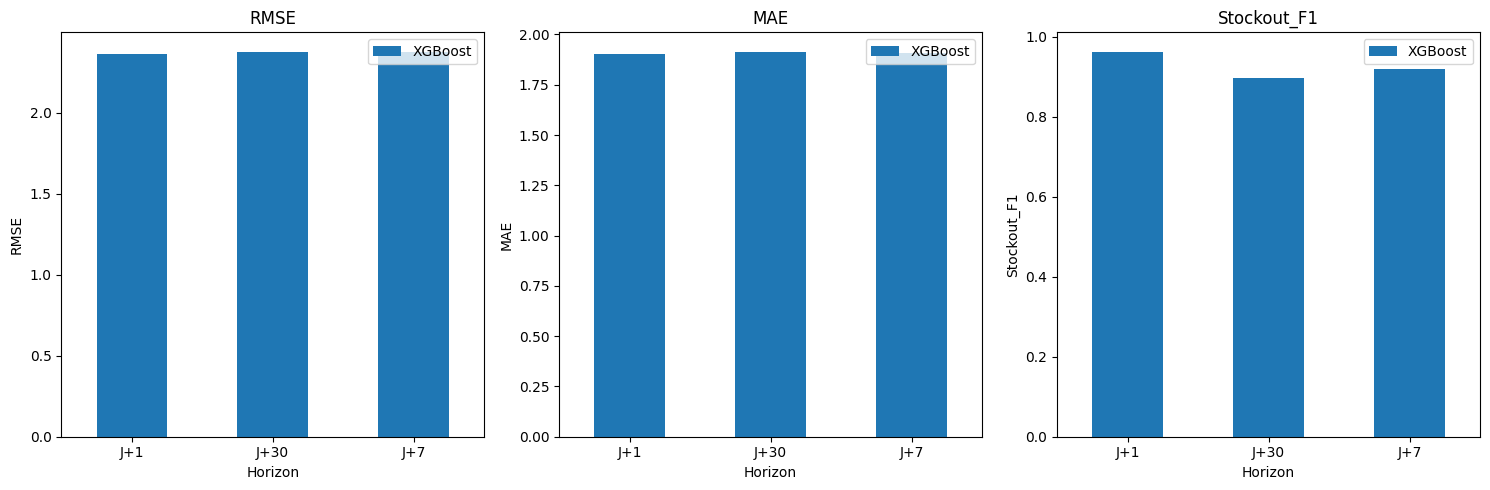

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ["RMSE", "MAE", "Stockout_F1"]

for idx, metric in enumerate(metrics):
    pivot = results_df_A.pivot(index="Horizon", columns="Model", values=metric)
    pivot.plot(kind="bar", ax=axes[idx], title=metric)
    axes[idx].set_ylabel(metric)
    axes[idx].tick_params(axis="x", rotation=0)
    axes[idx].legend()

plt.tight_layout()
plt.show()


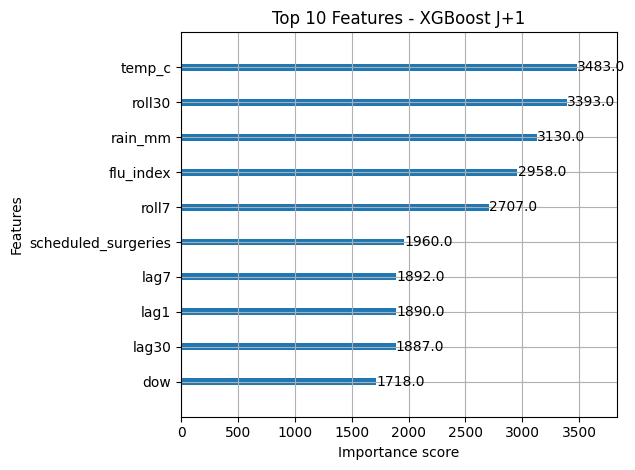

In [33]:
import xgboost as xgb
import matplotlib.pyplot as plt

model_j1 = results[1]["model"]
xgb.plot_importance(model_j1, max_num_features=10, title="Top 10 Features - XGBoost J+1")
plt.tight_layout()
plt.show()



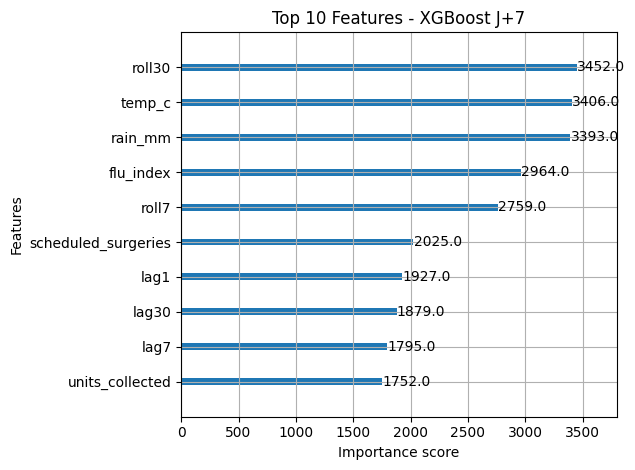

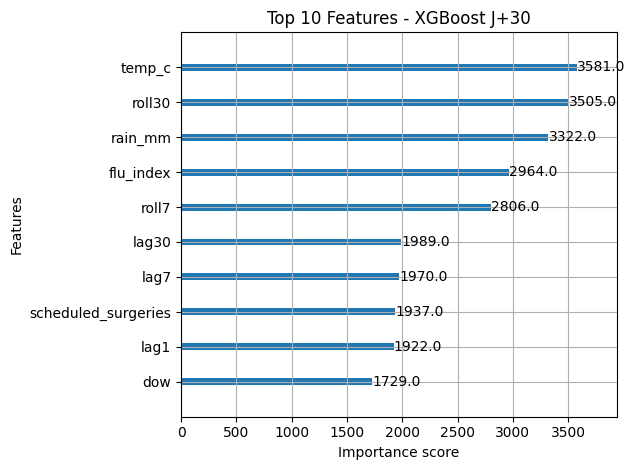

In [34]:
for H in [7,30]:
    model = results[H]["model"]
    xgb.plot_importance(model, max_num_features=10, title=f"Top 10 Features - XGBoost J+{H}")
    plt.tight_layout()
    plt.show()

In [23]:
import joblib

out_path = model_dir / "models" / "xgb_demand_forecast_j+1.pkl"
out_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(results[1]["model"], out_path)
print("Saved:", out_path)


Saved: d:\Projects\pios\ml-backend\models\xgb_demand_forecast_j+1.pkl


In [24]:
import joblib

out_path = model_dir / "models" / "xgb_demand_forecast_j+7.pkl"
out_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(results[7]["model"], out_path)
print("Saved:", out_path)


Saved: d:\Projects\pios\ml-backend\models\xgb_demand_forecast_j+7.pkl


In [25]:
import joblib

out_path = model_dir / "models" / "xgb_demand_forecast_j+30.pkl"
out_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(results[30]["model"], out_path)
print("Saved:", out_path)


Saved: d:\Projects\pios\ml-backend\models\xgb_demand_forecast_j+30.pkl


In [ ]:
from UniversalModelExporter import UniversalModelExporter
UniversalModelExporter.export_xgboost(
    model=results[30]["model"],
    output_path="xgb_demand_forecast_j+30.pkl",
    description="XGBoost for demand forecasting",
    feature_names=results[30]["feature_names"]
    )

📦 [XGBoost] Saved to xgb_demand_forecast_j+30.pkl


In [37]:
print(results[30]["feature_names"])

['dow', 'weekend', 'month', 'holiday', 'temp_c', 'rain_mm', 'flu_index', 'trauma_cases', 'scheduled_surgeries', 'donation_campaign', 'supply_shock', 'stock_start', 'units_collected', 'wastage', 'lag1', 'lag7', 'lag30', 'roll7', 'roll30', 'hospital_East', 'hospital_North', 'hospital_West', 'blood_type_A-', 'blood_type_AB+', 'blood_type_AB-', 'blood_type_B+', 'blood_type_B-', 'blood_type_O+', 'blood_type_O-']
